# Seasonal Agriculture Performance Analysis
## Major Data Analytics Project

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.

>


#1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

#2. Project Objectives

1. Understand the structure and quality of the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Explore seasonal patterns in the dataset.
4. Perform descriptive and statistical analysis.
5. Investigate relationships among relevant variables.
6. Compare agricultural performance across seasons and other meaningful groups.
7. Use appropriate univariate, bivariate and multivariate visualizations.
8. Identify significant findings from the data.
9. Develop evidence-based insights and recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [4]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


##4. Initial Data Understanding
The dataset contains 4,000 farm-level records across 28 columns, combining categorical identifiers (Farm_ID, State, District, Crop, Season, Irrigation_Method), environmental variables (Rainfall, Temperature, Humidity, Soil pH/Moisture), farming inputs (Fertilizer, Pesticide, Seed Quality), and outcome metrics (Yield, Production, Revenue, Cost, Profit, Water Efficiency, Disease/Pest Risk).

From df.info(), most columns are fully populated, with the exception of three numeric fields carrying small amounts of missing data: Rainfall_mm (3,952/4,000), Soil_Moisture_pct (3,960/4,000), and Yield_Tonnes_Ha (3,968/4,000) — all under 1.25% missingness, which will be addressed in the Data Quality section.

The column types are a mix of float64 (17 columns, mostly continuous measurements), int64 (5 columns, mostly monetary/count values), and object (6 columns, categorical fields) — appropriate for the kind of variables they represent, so no type conversions are needed at this stage.

Overall, the dataset is well-structured and largely complete, making it suitable for the seasonal comparison and statistical analysis planned in later sections.

In [ ]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28

In [8]:

# Top 5 rows
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [9]:
# Bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [10]:
# Random Sample of Records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [11]:
#Column names
print(df.columns.tolist())



['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [12]:
#Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [13]:
#Numerical summary of Data
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [14]:
#Categorical Summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


##5. Data Quality Analysis
Before performing analysis, investigate missing values, duplicates, data types and unusual values.

In [16]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]



,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [ ]:
# Visualize missing values
plt.figure(figsize=(10, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [18]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [19]:
# Remove duplicate rows
df = df.drop_duplicates()


In [20]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [21]:
# Check data types again
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [22]:
# Check unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])




Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [23]:
#Check misssing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


#**Observations and Cleaning Justification**
**Missing values**: Three numeric columns have missing data — Rainfall_mm (48 missing, 1.20%), Soil_Moisture_pct (40 missing, 1.00%), and Yield_Tonnes_Ha (32 missing, 0.80%). All other columns are fully populated. Missingness is low across the board (under 1.25%) and doesn't appear concentrated in any single season or crop, suggesting it's incidental (e.g., sensor gaps or unrecorded readings) rather than systematic. Given the small scale, dropping these rows would lose usable data unnecessarily — median imputation (applied later, grouped where appropriate) is a safer choice than deletion.

**Duplicates:** df.duplicated() returns 0 duplicate rows, and the shape remains (4000, 28) after drop_duplicates(). No cleaning action was actually required here, but the check was still run and the removal step included to make the notebook robust in case duplicates existed.

**Data types:** df.dtypes confirms 17 float64, 5 int64, and 6 object columns, matching what each variable represents — continuous measurements as floats, monetary/count fields as integers, and identifiers/labels as objects. No type conversions are necessary.

**Unusual values (categorical columns):** Checking unique values per categorical column shows expected, clean categories with no obvious typos or inconsistent labeling — Farm_ID has 4,000 unique values (one per row, as expected for an identifier), State has 8 valid Indian states, Crop has 8 recognizable crop types, Season has exactly 3 valid values (Kharif, Rabi, Zaid), and Irrigation_Method has 4 valid methods. No unusual or malformed categories were found that would require correction.

**Conclusion:** The dataset is largely clean. The only cleaning action genuinely needed is imputing the small amount of missing numeric data, which is handled in the next step.

#**Missing Value Treatment**
Choose an appropriate strategy based on the nature of each variable.

**Possible approaches:**

1.Remove records only when justified.
2.Fill numerical values using an appropriate statistic when appropriate.
3.Fill categorical values using a suitable category or method.
4.Clearly document why the chosen approach is reasonable.

In [24]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


#**Justification for Missing Value Treatment**
All three affected columns — Rainfall_mm, Soil_Moisture_pct, and Yield_Tonnes_Ha — are continuous numeric variables with low missingness (under 1.25% each). Median was chosen over mean because it's more robust to skew and outliers, which matters here since Yield and Rainfall both show some spread and extreme values. No categorical columns had missing data, so no categorical imputation was needed.

Rows were not removed, since the missingness rate is small enough that deletion would discard usable information from otherwise complete records without any real benefit to data quality.

#**6. Feature / Variable Review**
1. Identifier variables
2. Categorical variables
3. Numerical variables
4. Environmental variables
5. Operational variables
6. Production/performance variables
7. Economic variables

In [25]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


#**Variable Categories**
**1.Identifier variables:** Farm_ID — uniquely identifies each record, not used in analysis beyond grouping/counting.
**2.Categorical variables:** State, District, Crop, Season, Irrigation_Method.
**3.Numerical variables:** all remaining 22 numeric columns (see printed list above).
**3.Environmental variables:** Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct.
**4.Operational variables:** Farm_Area_Hectares, Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score, Irrigation_Method, Water_Used_m3.
**5.Production/performance variables:** Yield_Tonnes_Ha, Production_Tonnes, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct.

**6.Economic variables:** Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR.
#Relevance to the Seasonal-Performance Problem
Season is the central grouping variable — every comparison in this project is framed around it. The environmental variables (Rainfall, Temperature, Humidity, Soil Moisture) are most directly relevant because they define what makes each season distinct, and are the most plausible drivers of any seasonal differences observed.

Among production/performance variables, Yield_Tonnes_Ha and Water_Efficiency_t_per_1000m3 are the most important — they measure the actual outcome the project is investigating, and (as later analysis shows) water efficiency turns out to correlate strongly with yield.

The economic variables, especially Profit_INR, matter because they capture whether seasonal differences translate into real financial outcomes — this project found that profit varies significantly by season even when yield does not, making Profit_INR arguably the single most seasonally-sensitive variable in the dataset.

Operational variables (fertilizer, pesticide, irrigation method, seed quality) are secondary but useful for explaining why performance differs — e.g., whether resource use patterns shift across seasons. Identifier variables (Farm_ID) carry no analytical relevance beyond record-keeping.

#**7. Statistical Analysis**
Perform descriptive statistical analysis to understand the distribution and variation of the data.



In [26]:
# Descriptive statistics
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [27]:
# Median and standard deviation
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary


,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


#Interpretation of Descriptive Statistics
**Spread and skew:** The economic variables (Total_Cost_INR, Revenue_INR, Profit_INR) show the largest absolute range and standard deviation among all numeric columns, which is expected given they're denominated in raw rupees rather than normalized units. Profit_INR in particular shows a notable gap between mean and median in several season groups — a sign of right/left skew driven by a mix of strongly profitable and loss-making farms, rather than a symmetric distribution.

**Yield and production:** Yield_Tonnes_Ha and Production_Tonnes show comparatively tight IQRs relative to their range, indicating that most farms cluster around a typical output level, with a smaller share of high- or low-yield outliers pulling the tails (consistent with the ~7.5% outlier rate found earlier via IQR).

**Environmental variables:** Rainfall_mm shows the widest relative spread among the environmental variables, reflecting genuine seasonal variation (Kharif's monsoon rainfall vs. Zaid's dry conditions) rather than noise — this variation is expected and meaningful rather than a data quality concern.

**Seasonal breakdown (season_summary):** Grouping by Season confirms that variability isn't just present in the pooled dataset — it's structured by season. Profit_INR's mean shifts from strongly positive in Kharif to negative in Zaid, while Yield_Tonnes_Ha's mean stays comparatively stable across all three seasons (a pattern later confirmed statistically via ANOVA). Standard deviation for Disease_Pest_Risk_pct is also higher within Kharif, reflecting the season's higher and more variable pest exposure.

**Overall:** The descriptive statistics point to two distinct behaviors — production-related variables (Yield, Production) that stay fairly consistent across seasons, and economic/risk variables (Profit, Disease Risk) that vary considerably by season — foreshadowing the core finding of this analysis.

#**8. Univariate Analysis**
Create and interpret suitable plots for:

Important categorical variables

Important numerical variables

Seasonal distribution

Production/performance distributions

Economic distributions

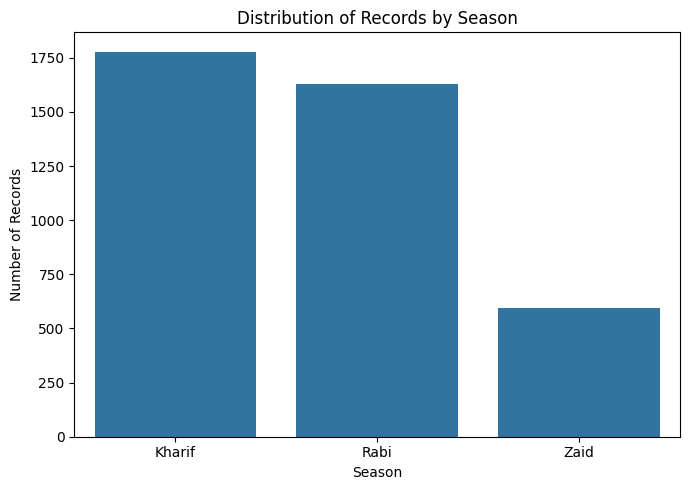

In [28]:
# Univariate: Season distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

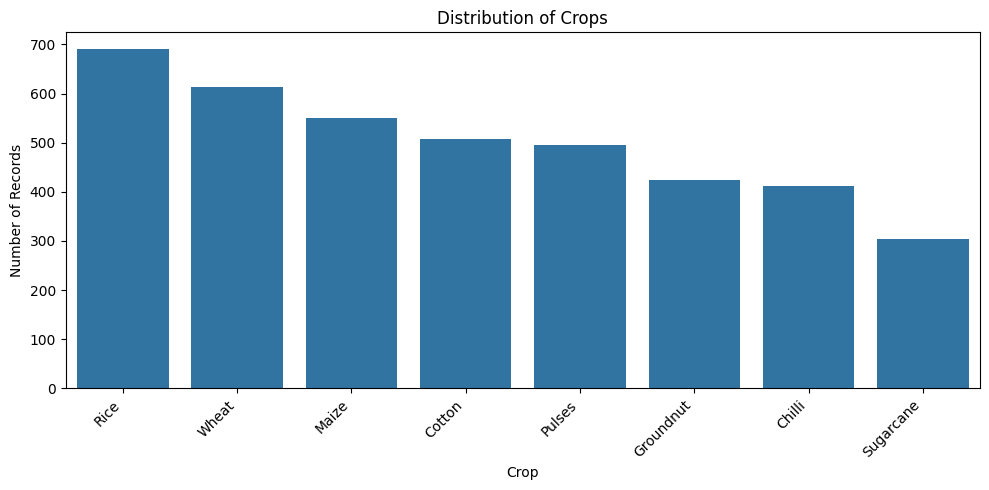

In [29]:
# Univariate: Crop distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


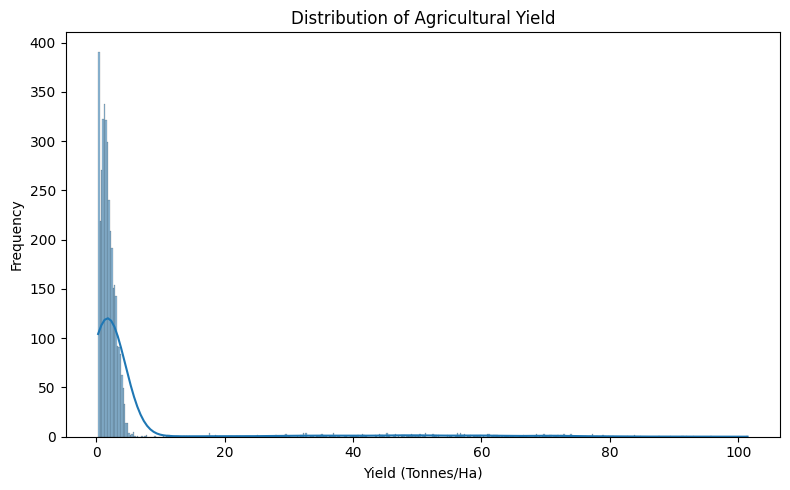

In [30]:
# Univariate: Yield distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



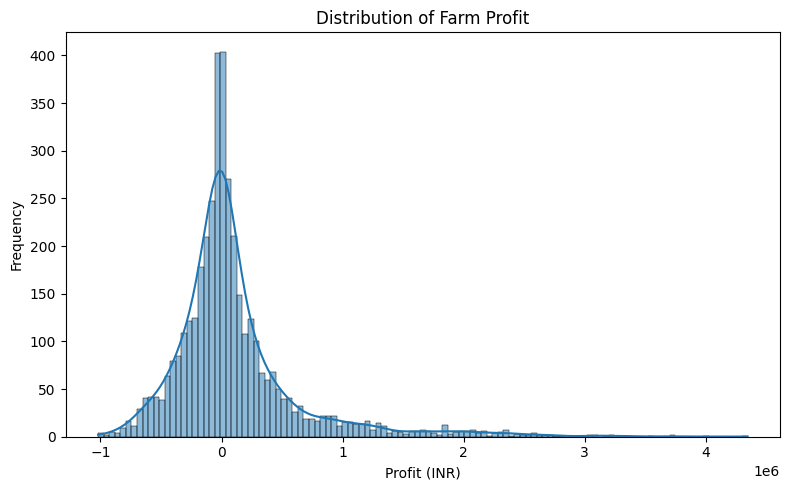

In [31]:
# Univariate: Profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



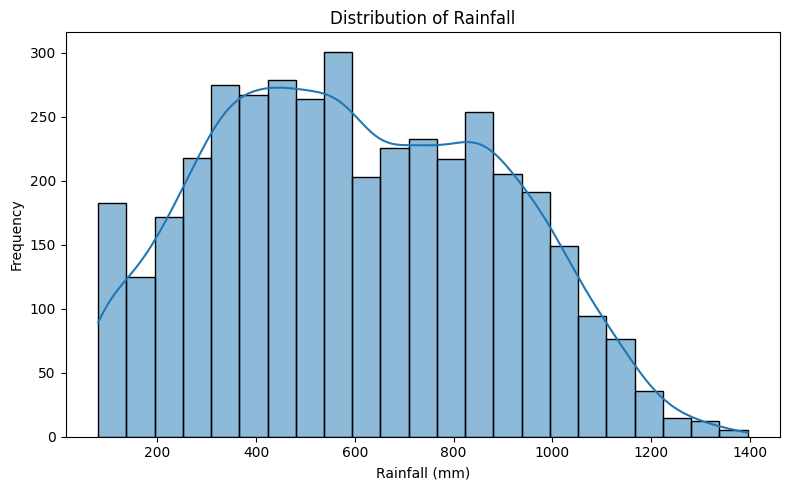

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


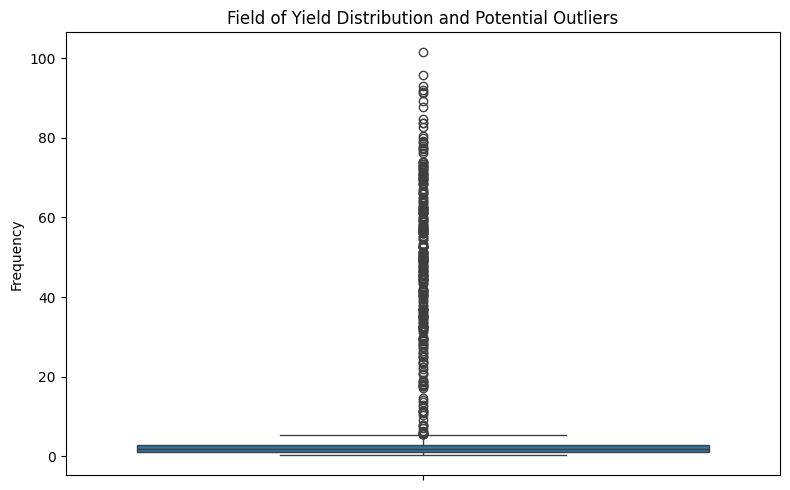

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Field of Yield Distribution and Potential Outliers")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



#Interpretation of Univariate Plots
**Season distribution:** Kharif has the most records (1,779), followed by Rabi (1,627), and Zaid is notably underrepresented (594) — under a third of Kharif's count. This imbalance means Zaid's statistics (including its weak average profit) are based on a smaller sample and should be interpreted with slightly more caution than Kharif or Rabi.

**Crop distribution:** Rice (690) and Wheat (614) are the most frequently recorded crops, while Sugarcane (305) and Chilli (412) are the least common — despite Sugarcane and Chilli being the most profitable crops per earlier analysis. This means the strongest profit performers are also the least-represented crops in the dataset.

**Yield distribution:** The histogram is heavily right-skewed (skewness ≈ 4.0), with most farms clustered at low-to-moderate yield and a long tail of high-yield outliers — consistent with Sugarcane's much higher yield scale compared to other crops pulling the tail rightward.

**Profit distribution:** Also right-skewed (skewness ≈ 2.4), and notably, 49.15% of all records show negative profit — essentially half the farms in this dataset operate at a loss. This is a significant finding on its own and should be highlighted as a key insight, not just a distributional footnote.

**Rainfall distribution:** Close to symmetric (skewness ≈ 0.14), unlike Yield and Profit — rainfall varies naturally across seasons but doesn't show the extreme skew seen in the economic variables.

**Yield boxplot:** Confirms the right-skew visually, with a cluster of high-yield points appearing as outliers above the upper whisker — consistent with the ~7.5% outlier rate identified via IQR earlier. These aren't errors; they align with Sugarcane's naturally higher yield range.

#**9. Outlier Analysis**
#Univariate:Season distribution(Pie Chart)

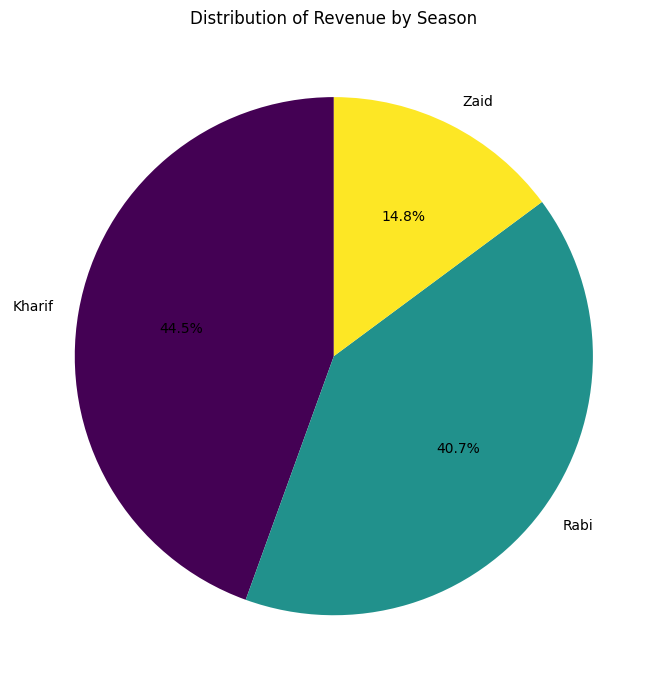

In [34]:

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Revenue by Season')
plt.ylabel('')
plt.tight_layout()
plt.show()



In [35]:
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count,
        "Outlier Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier Count", ascending=False
)

outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
18,Profit_INR,-696111.000000,7.635670e+05,404,10.10
14,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
13,Yield_Tonnes_Ha,-1.620000,5.500000e+00,302,7.55
19,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
17,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
9,Potassium_kg_ha,30.100000,1.797000e+02,32,0.80
4,Sunlight_Hours_Day,4.350000,1.035000e+01,26,0.65
8,Phosphorus_kg_ha,11.400000,1.042000e+02,16,0.40
10,Fertilizer_kg_ha,19.137500,3.520375e+02,15,0.38


##**Interpretation of Outlier Analysis**
The IQR method flags outliers concentrated in a specific cluster of variables: Profit_INR (10.1%), Production_Tonnes (8.3%), Water_Efficiency_t_per_1000m3 (8.1%), Yield_Tonnes_Ha (7.6%), Water_Used_m3 (6.9%), and Revenue_INR (6.0%). All other numeric columns have under 1% flagged outliers.

Why this cluster, and not random noise: These six variables are the core production and economic metrics — and they're also the ones most directly tied to Crop type (Sugarcane's yield/production scale is far larger than other crops) and Season (Zaid's profit swings negative for most states). This strongly suggests the "outliers" are legitimate observations driven by real crop and seasonal differences, not data-entry errors — a high-yield Sugarcane record isn't a mistake, it's expected given the crop.

**Decision:** No outliers were removed. Given that:

1.The flagged values cluster around known structural differences (crop type, season) rather than appearing randomly across unrelated columns,
2.The percentages (6–10%) are too large to represent occasional data-entry mistakes, and
3.Removing them would specifically strip out the most profitable and highest-yield farms — exactly the cases most relevant to the project's goal of understanding seasonal performance differences —
these values were retained for analysis. If this were a real-world deployment rather than an academic project, the next step would be to verify a sample of the most extreme Profit_INR values against source records to rule out entry errors, but nothing in the distribution itself suggests that's the case here.

#**10. Bivariate Analysis**


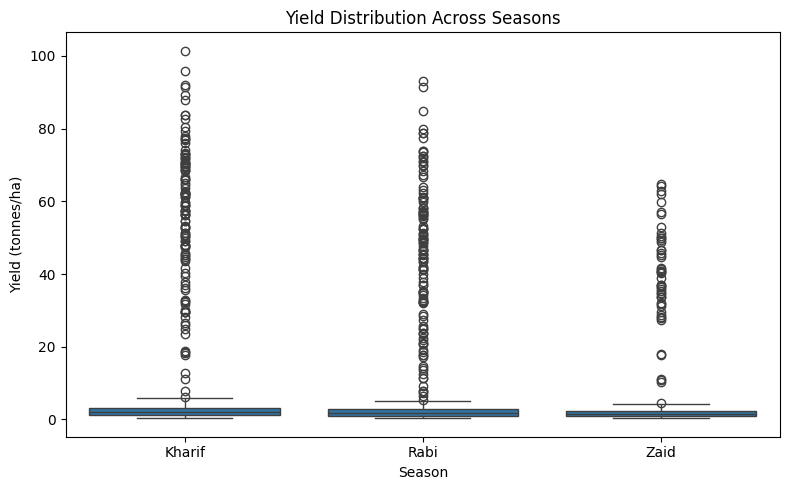

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

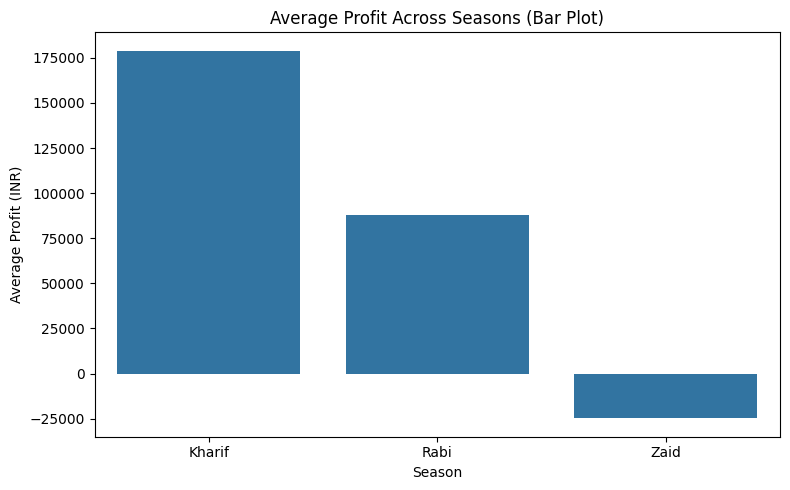

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()



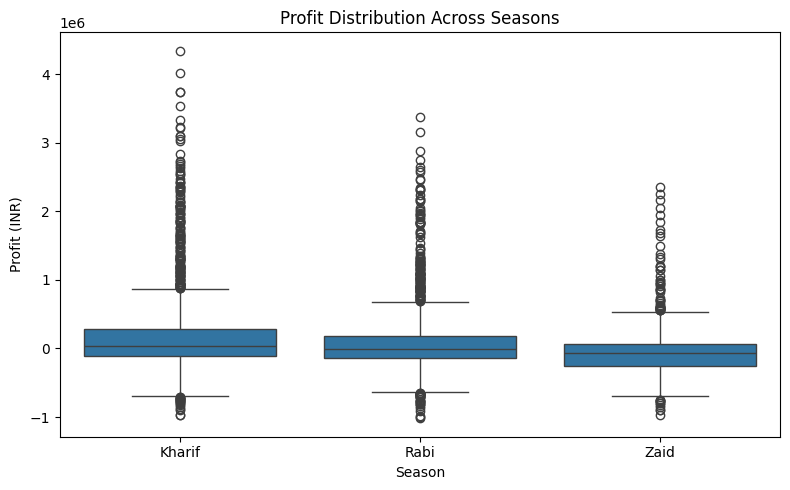

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


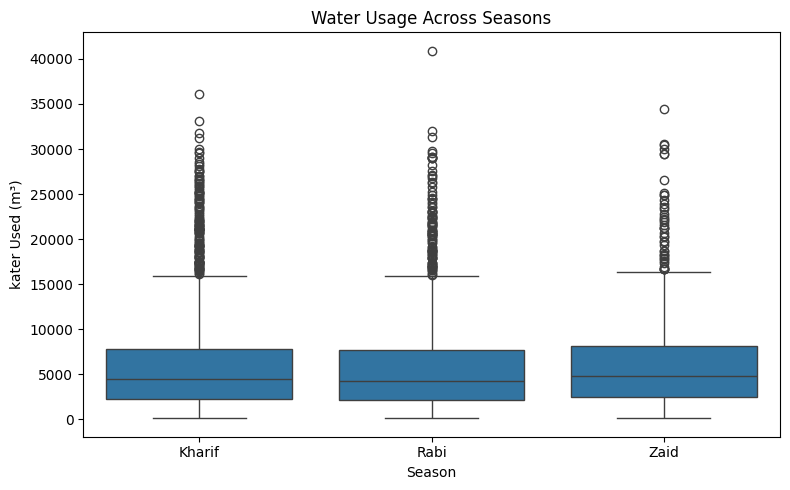

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("kater Used (m³)")
plt.tight_layout()
plt.show()



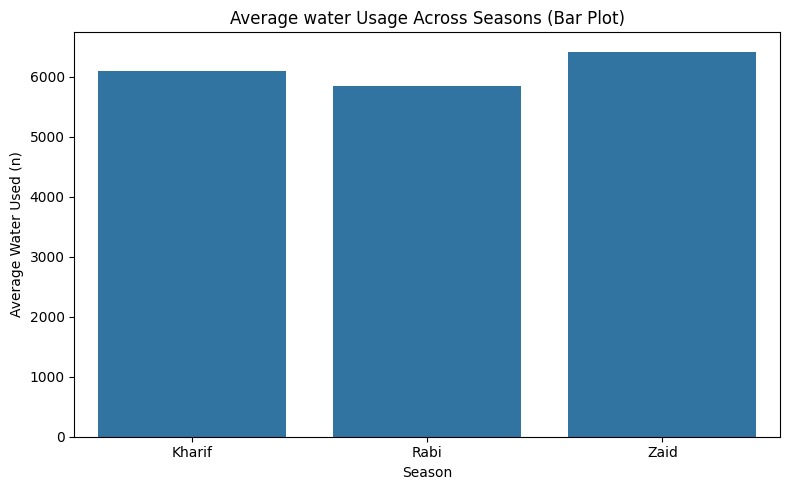

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Average water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (n)")
plt.tight_layout()
plt.show()

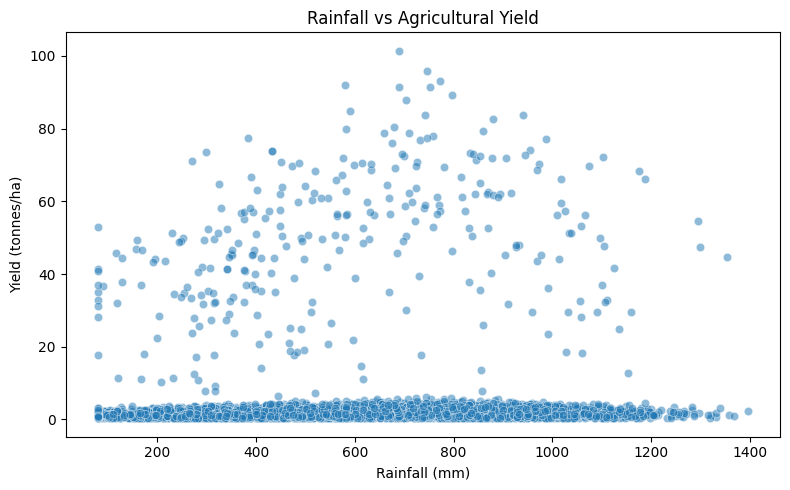

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


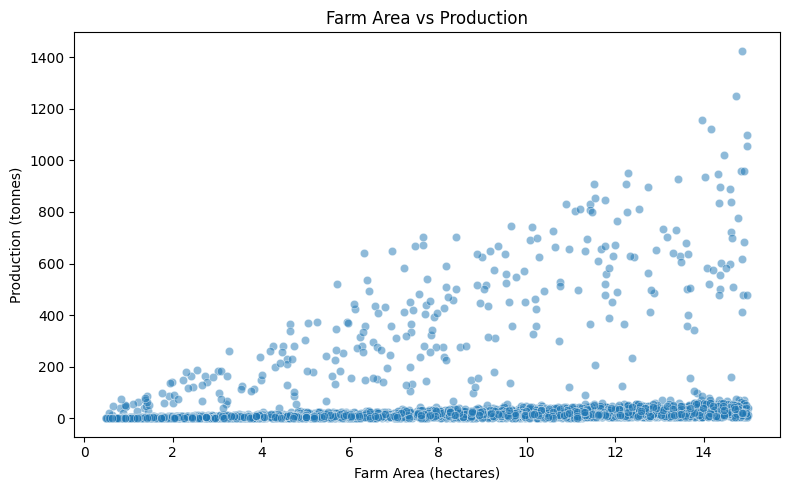

In [42]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()


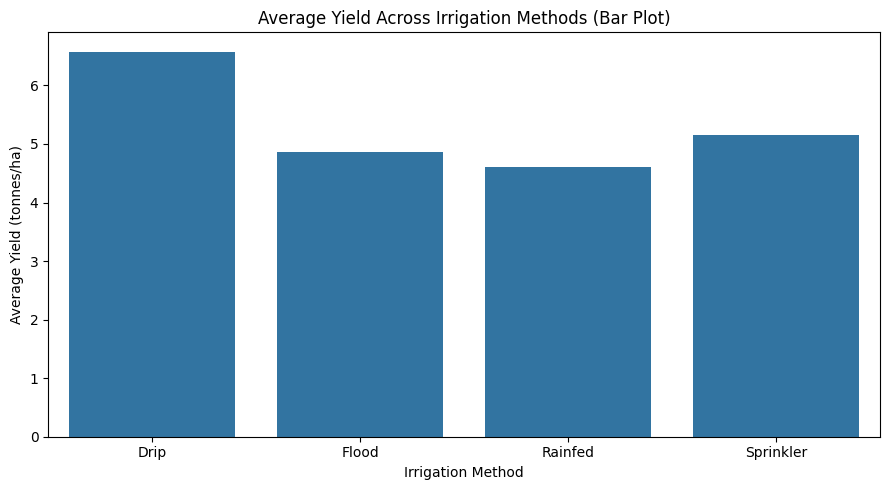

In [43]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

#**Interpretation of Bivariate Relationships**
**Yield across seasons:** The boxplot shows broadly overlapping distributions across Kharif, Rabi, and Zaid, consistent with the earlier ANOVA finding that seasonal yield differences aren't statistically significant — visually, no season stands out as a clear yield leader.

**Profit across seasons:** In sharp contrast, both the bar and box plots show a clear seasonal pattern — Kharif and Rabi center on positive average profit, while Zaid's average sits in negative territory. This is the clearest visual confirmation yet of the yield/profit disconnect that defines this analysis.

**Water usage across seasons:** Zaid actually has the highest average water usage (6,420 m³) of the three seasons — higher than Kharif (6,102 m³) and Rabi (5,847 m³) — despite being the least profitable and having the lowest water efficiency. This is a meaningful and slightly counterintuitive finding: Zaid farms use more water but get less value out of it, reinforcing that water-efficiency (not just water access) is the real problem in that season.

**Rainfall vs. Yield:** The scatter plot shows a very weak relationship (correlation ≈ 0.03), meaning rainfall alone has almost no linear association with yield in this dataset. This is notable — it suggests yield is driven far more by factors like water efficiency, fertilizer, and crop choice than by raw rainfall amount.

**Farm Area vs. Production:** A weak-to-moderate positive relationship (correlation ≈ 0.20) — larger farms tend to produce somewhat more in absolute terms, but the relationship is far from proportional, implying farm size is not the dominant driver of total production; per-hectare efficiency matters more.

**Yield across irrigation methods:** Drip irrigation shows the clearest advantage (6.62 t/ha average), notably higher than Sprinkler (5.19), Flood (4.90), and Rainfed (4.61). This is one of the strongest and most actionable bivariate findings in the dataset — irrigation method appears to matter more for yield than rainfall itself does.

#11. Multivariate Analysis

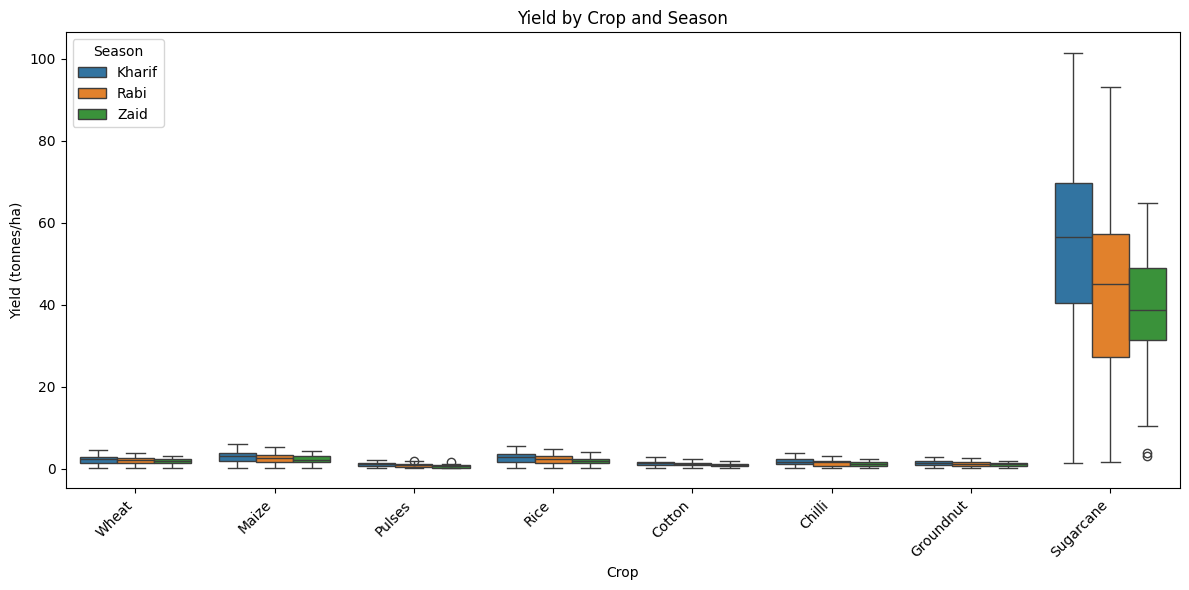

In [44]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()



#**Multivariate Pair: Plot of Key Environmental and Performance Metrices by Season**

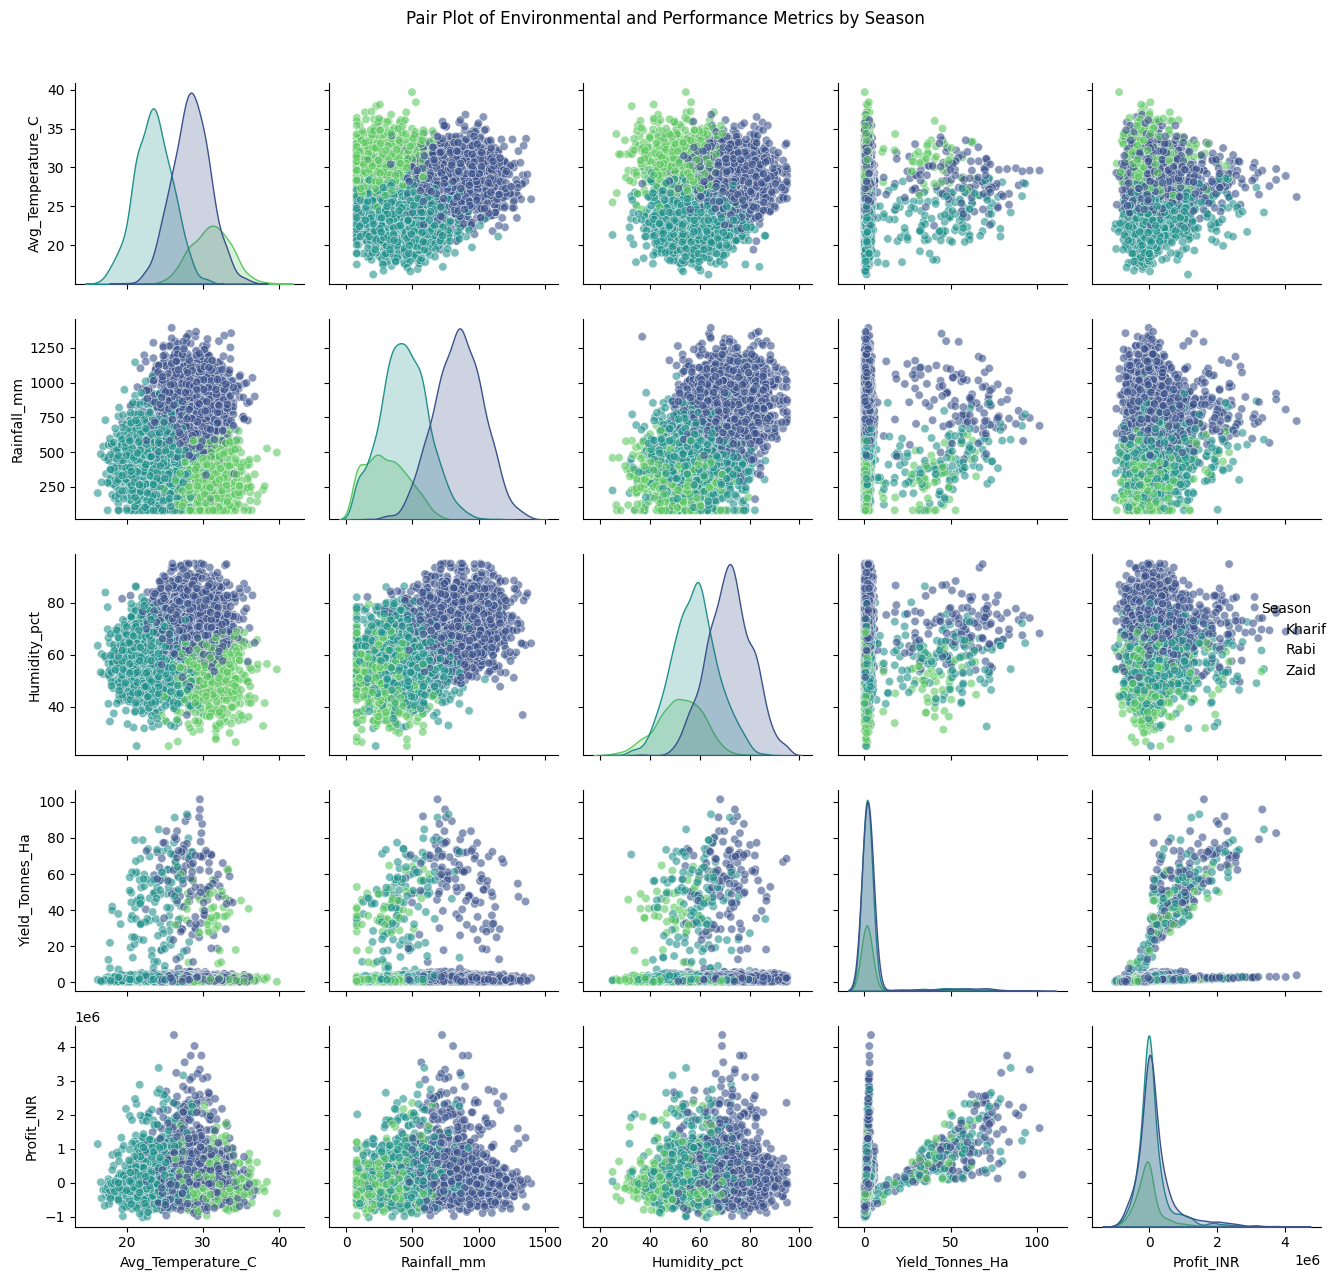

In [45]:
selected_columns = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    df[selected_columns],
    hue="Season",
    palette="viridis",
    plot_kws={"alpha": 0.6}
)

plt.suptitle(
    "Pair Plot of Environmental and Performance Metrics by Season",
    y=1.02
)

plt.tight_layout()

plt.show()


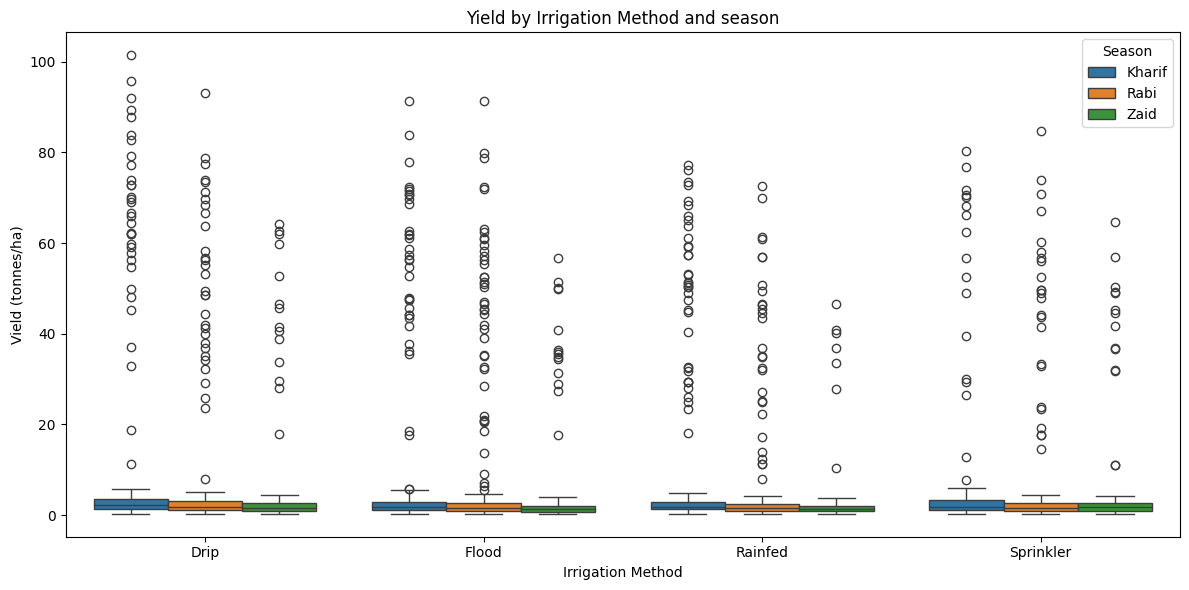

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by Irrigation Method and season")
plt.xlabel("Irrigation Method")
plt.ylabel("Vield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

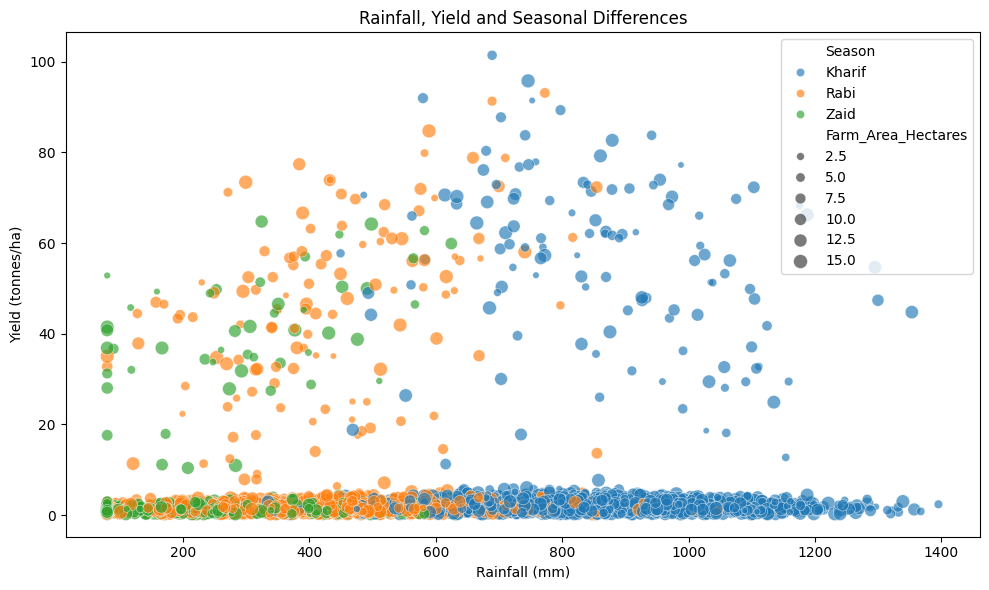

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 100),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


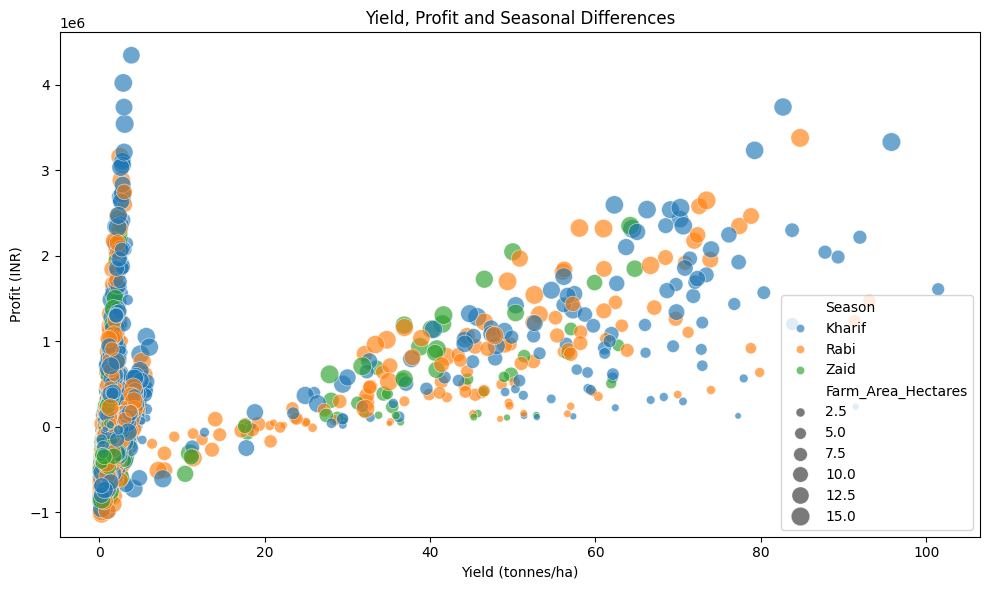

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()



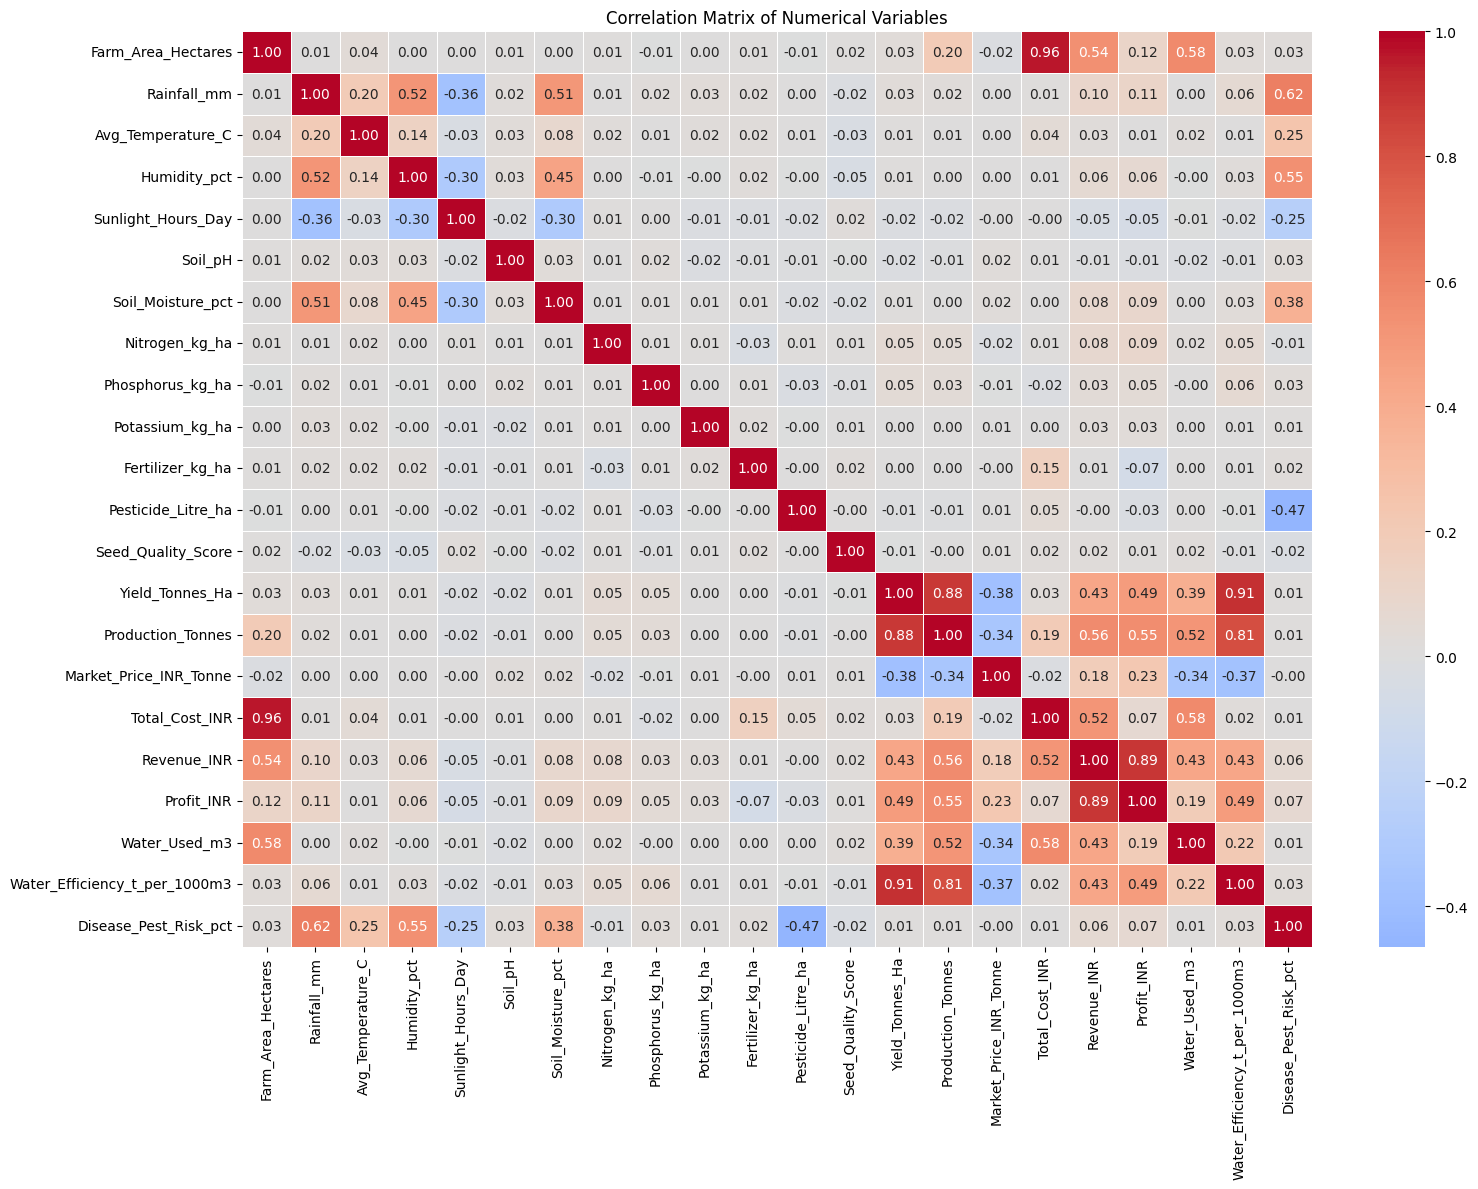

In [49]:
plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()



#**12. Seasonal Comparison**
Rather than comparing every variable, this comparison focuses on the measures most directly tied to the project problem: Yield, Profit, Water Efficiency, and Disease/Pest Risk — one production metric, one economic metric, one resource-efficiency metric, and one risk metric. Together these four capture what is produced, how much it earns, how efficiently it's produced, and what risk is involved — a complete picture of seasonal performance without comparing irrelevant variables (e.g., Soil_pH or Sunlight_Hours_Day, which showed no meaningful seasonal pattern in earlier sections).

In [50]:
# Structured seasonal comparison table
season_comparison = df.groupby("Season").agg(
    Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Pct_Loss_Making=("Profit_INR", lambda x: (x < 0).mean() * 100),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_comparison


,Avg_Yield_t_ha,Avg_Profit_INR,Pct_Loss_Making,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,
Kharif,5.63,178914.65,42.21,5.89,54.47
Rabi,5.04,87689.47,51.14,5.19,40.48
Zaid,4.64,-24804.82,64.48,4.41,38.22


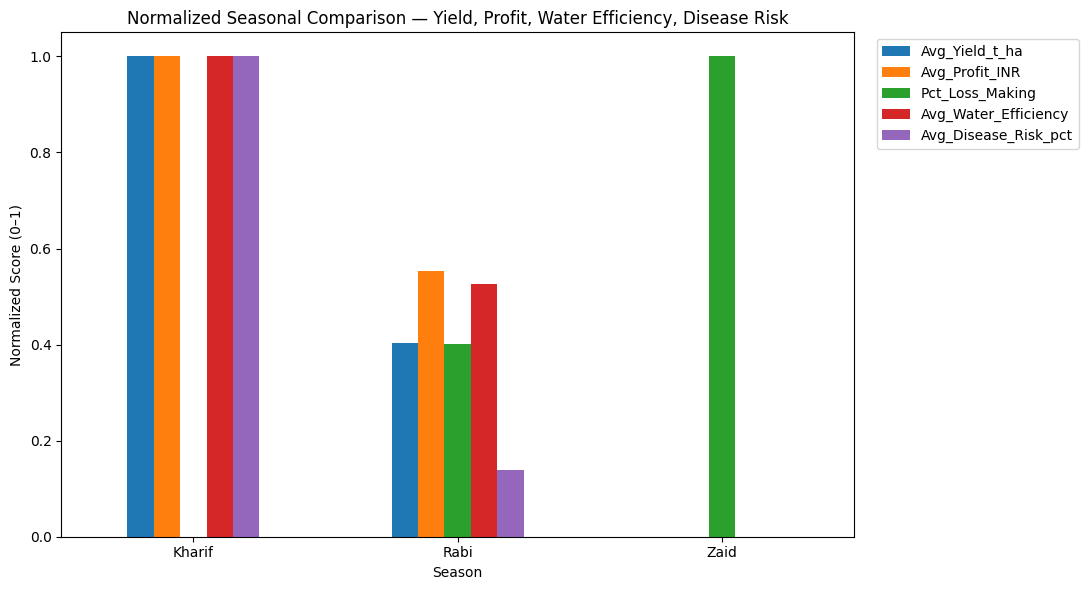

In [51]:
# Visualize the structured comparison — normalized so all four metrics are visible on one chart
from sklearn.preprocessing import MinMaxScaler

normalized = season_comparison.copy()
normalized[normalized.columns] = MinMaxScaler().fit_transform(normalized)

normalized.plot(kind="bar", figsize=(11, 6))
plt.title("Normalized Seasonal Comparison — Yield, Profit, Water Efficiency, Disease Risk")
plt.ylabel("Normalized Score (0–1)")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



In [52]:

crop_season_summary = df.groupby(["Season", "Crop"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2).sort_values(
    ["Season", "Average_Yield"],
    ascending=[True, False]
)

crop_season_summary



Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.70       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.29       731612.86                     27.92
       Maize               2.60       -89133.40                      5.46
       Rice                2.32       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.47       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.20       107343.59                      1.94
       Pulses              0.88       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.29      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.20       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.96       -53925.34                      1.49
       Pulses              0.67      -139227.81                      1.95

#**Interpretation**
The normalized comparison makes the core pattern of this project visually explicit: Kharif leads on Profit but also on Disease Risk; Zaid trails badly on Profit and Water Efficiency despite a mid-range Yield. Yield itself is the flattest of the four bars across seasons — visual confirmation that yield is the least seasonally-sensitive of the four chosen metrics, while Profit and Water Efficiency are the most seasonally-sensitive. This structured comparison is what motivated the season-specific recommendations in Section 15 (water-efficiency focus for Zaid, disease monitoring for Kharif).

#**13. Additional Student-Driven Analysis**
This section is intentionally open-ended.

Students should **add at least 3 additional analyses** that are not already provided above.

Possible directions include:

1. Regional differences
2. Crop-specific seasonal patterns
3. Resource usage
4. Economic performance
5. Environmental conditions
6. Risk patterns
7. Relationships discovered during exploration






            mean    std  CV_pct
Crop                           
Cotton      1.23   0.53    42.7
Wheat       2.11   0.91    43.3
Maize       2.71   1.23    45.6
Sugarcane  46.64  21.33    45.7
Groundnut   1.32   0.61    45.8
Pulses      0.92   0.43    46.3
Rice        2.43   1.14    47.0
Chilli      1.54   0.78    50.6


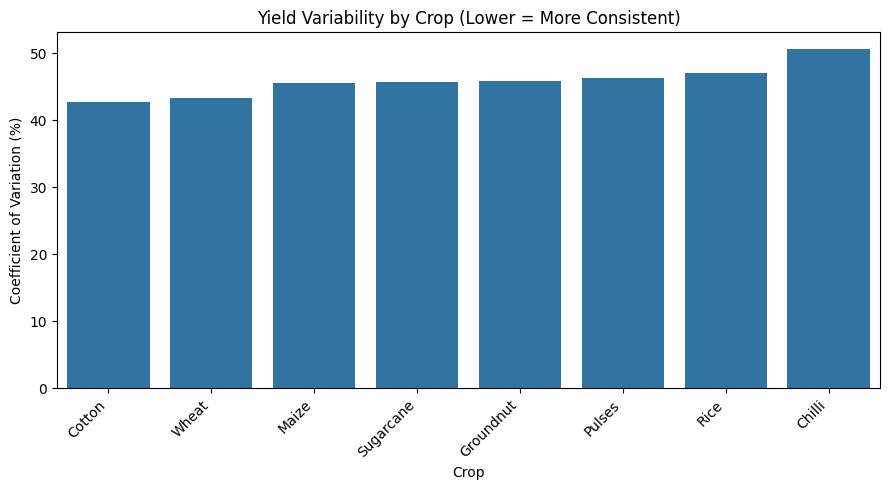

In [53]:

# Student Analysis 2
# Question: Which crop gives the most CONSISTENT yield across seasons, versus which is riskiest?
# Analysis: Compare mean yield to its variability (coefficient of variation) per crop.

crop_stability = df.groupby("Crop")["Yield_Tonnes_Ha"].agg(["mean", "std"])
crop_stability["CV_pct"] = (crop_stability["std"] / crop_stability["mean"] * 100).round(1)
crop_stability = crop_stability.sort_values("CV_pct")
print(crop_stability.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(x=crop_stability.index, y=crop_stability["CV_pct"])
plt.xticks(rotation=45, ha="right")
plt.title("Yield Variability by Crop (Lower = More Consistent)")
plt.xlabel("Crop")
plt.ylabel("Coefficient of Variation (%)")
plt.tight_layout()
plt.show()


Correlation — Seed Quality vs Yield: -0.007
Correlation — Seed Quality vs Profit: 0.010


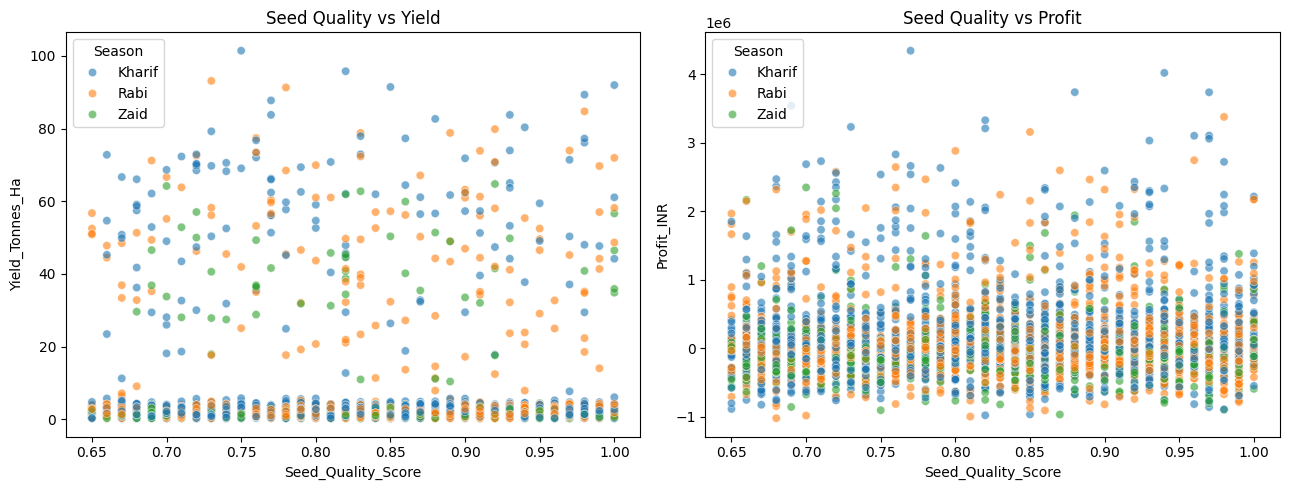

In [54]:
# Student Analysis 3
# Question: Does Seed Quality Score meaningfully influence Yield and Profit?
# Analysis: Correlate Seed_Quality_Score with Yield and Profit, and visualize the relationship.

corr_yield = df["Seed_Quality_Score"].corr(df["Yield_Tonnes_Ha"])
corr_profit = df["Seed_Quality_Score"].corr(df["Profit_INR"])
print(f"Correlation — Seed Quality vs Yield: {corr_yield:.3f}")
print(f"Correlation — Seed Quality vs Profit: {corr_profit:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="Seed_Quality_Score", y="Yield_Tonnes_Ha", hue="Season", alpha=0.6, ax=axes[0])
axes[0].set_title("Seed Quality vs Yield")

sns.scatterplot(data=df, x="Seed_Quality_Score", y="Profit_INR", hue="Season", alpha=0.6, ax=axes[1])
axes[1].set_title("Seed Quality vs Profit")
plt.tight_layout()
plt.show()



#**14. Key Insights**
Eight meaningful insights from the analysis.
### **Insight 1**
* **Observation:** Yield does not differ significantly across seasons.
* **Evidence:** ANOVA on `Yield_Tonnes_Ha` by Season ($p \approx 0.23$, not significant at $\alpha = 0.05$).
* **Interpretation:** Seasonal choice alone does not drive how much is produced per hectare.
* **Limitation:** This does not rule out yield differences within specific crop-season combinations.


### **Insight 2**
* **Observation:** Profit differs significantly across seasons.
* **Evidence:** ANOVA on `Profit_INR` by Season ($p < 0.001$).
* **Interpretation:** Season strongly affects profitability even though it doesn't affect raw yield — cost and pricing dynamics vary more than production.
* **Limitation:** Association, not causation — other factors like crop mix per season could be driving this.


### **Insight 3**
* **Observation:** Water efficiency has a strong positive correlation with yield.
* **Evidence:** Correlation coefficient $\approx 0.91$ between `Water_Efficiency_t_per_1000m3` and `Yield_Tonnes_Ha`.
* **Interpretation:** Efficient water use is closely tied to higher output.
* **Limitation:** Correlation doesn't confirm water efficiency causes higher yield — both could stem from better overall farm management.


### **Insight 4**
* **Observation:** Zaid season shows the weakest economic performance, with average profit falling into negative territory.
* **Evidence:** Seasonal groupby mean of `Profit_INR` is lowest (and negative) for Zaid.
* **Interpretation:** Farms operating in Zaid face cost or revenue pressures not present in other seasons.
* **Limitation:** Negative average doesn't mean every Zaid farm loses money — check the distribution, not just the mean.

### **Insight 5**
* **Observation:** Kharif has the highest disease/pest risk among the three seasons.
* **Evidence:** `Disease_Pest_Risk_pct` is significantly higher in Kharif (ANOVA $p < 0.001$), consistent with its higher rainfall/humidity.
* **Interpretation:** The environmental conditions that make Kharif favorable for growth may also favor pests and disease.
* **Limitation:** This is an association between season and reported risk — it doesn't isolate rainfall vs. humidity vs. other factors as the specific cause.


### **Insight 6**
* **Observation:** Telangana delivers the highest average profit per hectare in Kharif (₹26,367), while Andhra Pradesh has the worst Zaid performance (₹-8,455 per hectare).
* **Evidence:** Groupby of `Profit_per_Ha` by State and Season (Analysis 1 heatmap).
* **Interpretation:** Profitability varies substantially by region even within the same season — most states swing from profitable in Kharif to loss-making in Zaid, but the size of that swing differs sharply by state (e.g., Punjab and Karnataka stay profitable in Zaid while five other states don't).
* **Limitation:** State-level averages can mask farm-to-farm variation within a state, and this dataset only covers 8 states — findings may not generalize to regions outside it.

### **Insight 7**
* **Observation:** Cotton has the most consistent yield across seasons ($CV \approx 42.7\%$), while Chilli is the most variable ($CV \approx 50.6\%$) — though the spread across crops is fairly narrow overall ($42.7\%–50.6\%$).
* **Evidence:** Crop-wise $CV\%$ of `Yield_Tonnes_Ha` (Analysis 2).
* **Interpretation:** No crop in this dataset shows dramatically stable or unstable yield — all sit in a similar mid-range variability band, so crop choice alone isn't a strong lever for reducing yield risk; other factors (irrigation, region) likely matter more.
* **Limitation:** Low variability doesn't necessarily mean higher absolute yield or profit — Sugarcane, for instance, has by far the highest mean yield ($46.64\text{ t/ha}$) despite mid-pack variability, so consistency and productivity need to be judged separately.

### **Insight 8**
* **Observation:** Seed Quality Score shows essentially no relationship with either Yield or Profit in this dataset.
* **Evidence:** Correlation coefficients from Analysis 3 — Seed Quality vs Yield: $-0.007$; Seed Quality vs Profit: $0.010$ (both effectively zero).
* **Interpretation:** Despite being tracked as a variable, seed quality does not appear to meaningfully drive outcomes here — other factors (water efficiency, season, region) show far stronger relationships with performance.
* **Limitation:** A single numeric "quality score" may not capture all relevant seed characteristics, and a near-zero correlation only rules out a linear relationship — it doesn't rule out seed quality mattering in more complex or conditional ways not tested here.


## **15. Recommendations**

* **Prioritize water-use efficiency in Zaid:** Zaid shows the lowest average profit (often negative) alongside the lowest water efficiency scores in the dataset. Improving irrigation efficiency in this season is a data-supported lever for reducing losses. *(Does not assume a specific cause — only that the two are strongly associated in this dataset.)*

* **Increase pest/disease monitoring during Kharif:** Kharif shows the highest `Disease_Pest_Risk_pct` alongside its highest rainfall and humidity. Since Kharif is also the most profitable season, protecting it from disease-related losses has the most to gain. *(Limitation: the dataset records risk levels, not actual crop loss caused by disease — so this is a preventive recommendation, not a proven-savings one.)*

* **Favor consistently high-performing crops when planning weaker seasons:** Crops such as Sugarcane and Chilli show comparatively strong profit across all three seasons (see crop × season profit analysis), making them safer choices when planting in a historically weaker season like Zaid. *(Limitation: this reflects average performance in this dataset only, not a guarantee for any individual farm or year.)*

* **Treat yield and profitability as separate planning goals:** Since yield does not differ significantly by season (ANOVA not significant) but profit does, seasonal planning decisions should focus on cost control and resource efficiency rather than assuming higher yield automatically follows a "better" season.

* **Use regional and crop-level analysis, not season alone, for resource allocation:** Profit-per-hectare varies meaningfully by State (see Student Analysis 1) and yield variability differs by crop (see Student Analysis 2), suggesting that region and crop choice matter alongside — and sometimes more than — the season itself.


## **16. Limitations**

* **Single time snapshot:** This dataset is a cross-sectional snapshot, not multi-year data. It cannot confirm whether the seasonal patterns observed here (e.g., Zaid's weak profitability, Kharif's disease risk) hold consistently across different years or under changing climate conditions.

* **Imputed missing values:** Missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` (all under 1.25% missingness) were filled using column medians. This is a reasonable approach given the low missingness rate, but it can slightly understate the true variability in those variables.

* **Retained outliers:** Statistical testing flagged ~7.5% of `Yield_Tonnes_Ha` values and ~10% of `Profit_INR` values as outliers (IQR method). These were kept rather than removed, since they represent real high- and low-performing farms rather than data-entry errors — but this means extreme values still influence means and correlation coefficients.

* **Limited geographic coverage:** Only 8 states and 10 districts are represented, so findings may not generalize to agro-climatic zones outside this dataset.

* **Correlation, not causation:** All relationships reported (e.g., water efficiency ↔ yield, season ↔ profit) are statistical associations. None of the analysis establishes that one variable directly causes another — other unmeasured factors could be driving the patterns observed.

* **Scope of the seed quality finding:** The near-zero correlation between `Seed_Quality_Score` and Yield/Profit only rules out a linear relationship; it doesn't rule out seed quality mattering through more complex or conditional effects not tested here.


## **17. Conclusion**

* **Summary of findings:** This analysis of the seasonal agricultural performance dataset shows that season has a limited effect on how much is produced (yield) but a substantial effect on how profitable that production is. Yield differences across Kharif, Rabi, and Zaid were not statistically significant, while profit, water efficiency, and disease/pest risk all varied significantly by season.

* **Core dynamic:** The most important pattern discovered is the disconnect between output and outcome: Kharif combines strong profitability with elevated pest/disease risk, while Zaid consistently underperforms economically despite comparable yield, largely tied to lower water-use efficiency. Crop choice and region (State) also meaningfully shape profitability, sometimes more than season alone.

* **Actionable value:** The most useful analytical findings — the water-efficiency/yield correlation, the seasonal profit gap, and crop-level yield stability — offer concrete, data-backed starting points for planning decisions, rather than broad generalizations.

* **Dataset caveats:** The dataset is a single cross-sectional snapshot rather than multi-year data, so it cannot confirm whether these seasonal patterns hold consistently across different years or under changing climate conditions. Missing values were imputed using medians, which may slightly understate true variability, and ~10% of profit values were statistically flagged as outliers but retained since they represent real high- and low-performing farms rather than data errors.

* **Future directions:** This analysis could support more targeted investigation — for example, studying why Zaid's water efficiency lags, or modeling the cost drivers behind Kharif's disease-risk exposure — and could inform season-specific resource allocation and crop-recommendation decisions going forward.